# Summative Lab: DataVine Analytics

## Business Understanding & Problem Statement

### Overarching Business Objective: DataVine Analytics
DataVine Analytics delivers standardized, end-to-end machine learning prototypes across diverse industry verticals. The primary objective is to translate client domain challenges into structured ML workflows—combining exploratory data analysis, feature scaling, dimensionality reduction (PCA), hyperparameter tuning, and model evaluation to yield actionable business intelligence.

---

### Client 1: Wine Classification System
* **Business Problem:** A premium wine distributor faces inventory mislabeling and quality control inefficiencies caused by manual categorization of incoming wine shipments.
* **Data & Operational Bottleneck:** Wine varieties exhibit complex, high-dimensional chemical profiles (e.g., alcohol content, malic acid, flavonoids). Evaluating individual chemical parameters manually leads to classification errors and operational delays.
* **ML Solution Goal:** Develop an automated $k$-Nearest Neighbors ($k$-NN) classification pipeline integrated with Principal Component Analysis (PCA) to accurately identify wine varieties based on chemical attributes, optimizing model parameters through systematic hyperparameter tuning.

---

### Client 2: Agricultural Feed Recommendation Engine
* **Business Problem:** An agricultural supply company aims to improve customer satisfaction and drive sales by recommending comparable alternative feed products to farmers based on past performance metrics.
* **Data & Operational Bottleneck:** When primary feed products are out of stock or price-prohibitive, farmers require evidence-based product alternatives that deliver similar growth outcomes.
* **ML Solution Goal:** Utilize growth performance proxies (chicken weight outcomes across feed types) to construct a PCA-driven recommendation engine. Using cosine similarity metrics, the system suggests alternative feed products that yield equivalent performance.

---

### Client 3: Regional Crime Pattern Analysis
* **Business Problem:** A public policy research firm requires a data-driven framework to identify regional crime patterns across U.S. states to assist law enforcement agencies and decision-makers in strategic resource allocation.
* **Data & Operational Bottleneck:** Crime statistics cover multiple offense categories across varying population densities, making direct cross-regional comparisons difficult without uncovering underlying structural patterns.
* **ML Solution Goal:** Implement feature selection and 2D PCA dimensionality reduction, then evaluate hard clustering (K-Means) against probabilistic soft clustering (Gaussian Mixture Models) to identify natural regional risk profiles and policy insights.

In [4]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics.pairwise import cosine_similarity

## 1.Wine Classification.

In [5]:
# load dataset
wine = pd.read_csv('dataSets/wine.csv')
print(wine.shape)
wine.head()

(178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [6]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [7]:
# data types
wine.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

In [8]:
# summary
wine.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [9]:
# check missing values
wine.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

In [10]:
# check target
wine['target'].value_counts().sort_index()

target
0    59
1    71
2    48
Name: count, dtype: int64

In [11]:
# correlation
wine.corr()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720,-0.328222
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011,0.437776
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626,-0.049643
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597,0.517859
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351,-0.209179
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115,-0.719163
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193,-0.847498
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385,0.489109
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417,-0.499130
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100,0.265668


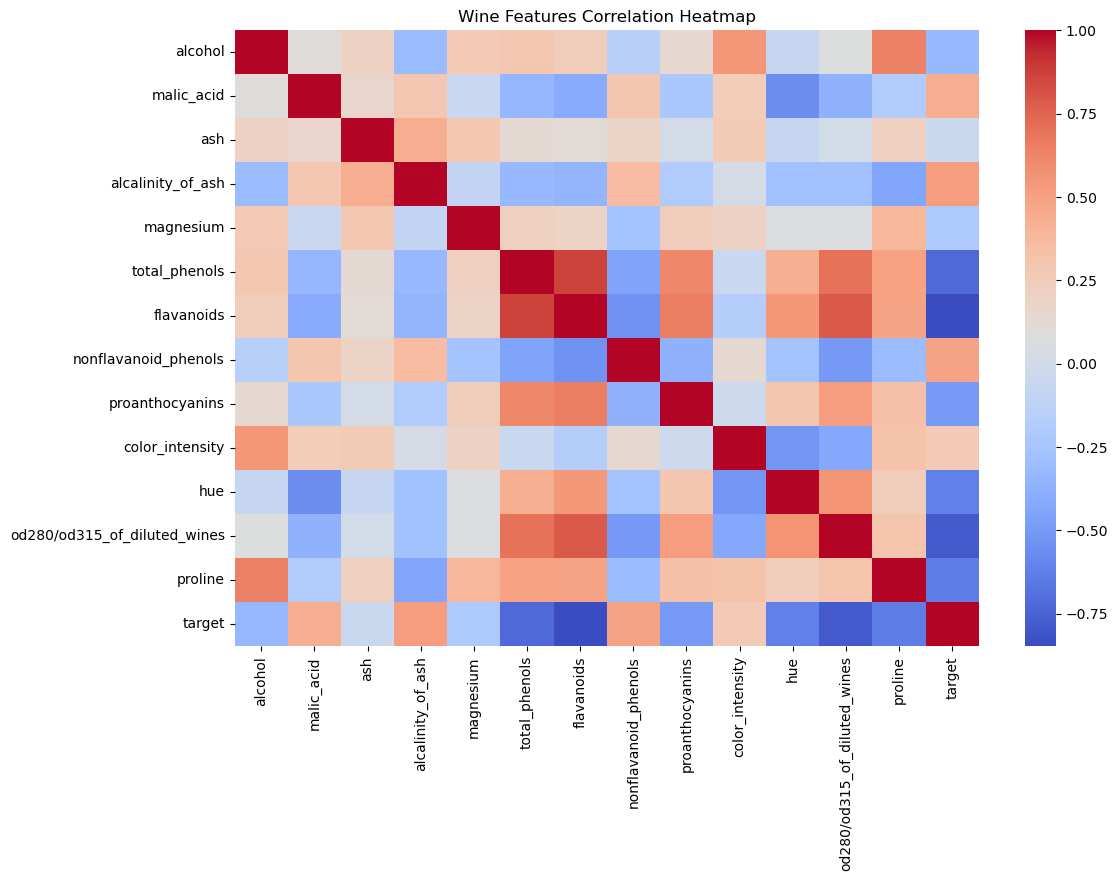

In [12]:
# correlation plot
plt.figure(figsize=(12, 8))
sns.heatmap(wine.corr(), cmap='coolwarm')
plt.title('Wine Features Correlation Heatmap')
plt.show()

<Axes: xlabel='target', ylabel='count'>

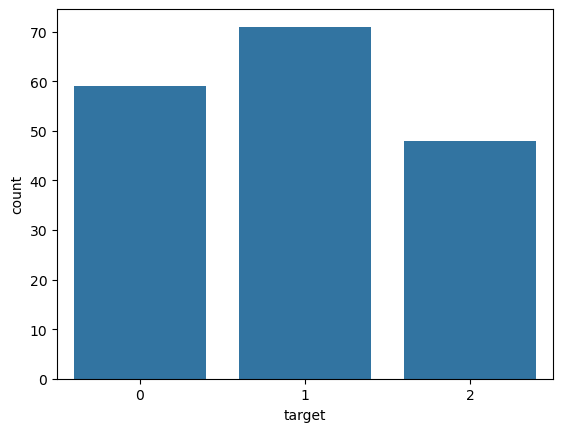

In [13]:
# target distribution
sns.countplot(x='target', data= wine)

In [14]:
# set features and target
X = wine.drop('target', axis=1)
y = wine['target']
# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Baseline model
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy = DummyClassifier(strategy='most_frequent')

dummy.fit(X_train, y_train)

baseline_pred = dummy.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, baseline_pred))

Baseline Accuracy: 0.3888888888888889


#### The baseline accuracy was 38.8%, providing a reference point for evaluating the performance of the trained classification models.

In [16]:
# standardize
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# PCA 
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [18]:
print("Original number of features:", X_train.shape[1])
print("Number of PCA components:", X_train_pca.shape[1])
print("Explained variance:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Original number of features: 13
Number of PCA components: 10
Explained variance: [0.35900066 0.18691934 0.11606557 0.07371716 0.0665386  0.04854582
 0.04195042 0.02683922 0.0234746  0.01889734]
Total explained variance: 0.9619487172898264


In [19]:
# KNN model
knn = KNeighborsClassifier()
# parameters
param_grid = {
    'n_neighbors': range(1, 21),
    'metric': ['euclidean', 'manhattan']
}
# set up gridsearchcv
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)
# fit using pca
grid_search.fit(X_train_pca, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'metric': 'euclidean', 'n_neighbors': 20}
Best cross-validation accuracy: 0.9647783251231526


In [20]:
# evaluate unseen data
best_knn = grid_search.best_estimator_

y_pred = best_knn.predict(X_test_pca)

In [21]:
# check accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9722222222222222


In [22]:
# classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.93      0.96        14
           2       1.00      1.00      1.00         8

    accuracy                           0.97        36
   macro avg       0.98      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36



In [23]:
# SVM (Support Vector Model)
from sklearn.svm import SVC
svm = SVC() # create model
svm_params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
} # tune parameters
svm_grid = GridSearchCV(
    svm,
    svm_params,
    cv=5,
    scoring='accuracy'
)

svm_grid.fit(X_train_pca, y_train) # GridSearchCV
print("Best SVM parameters:", svm_grid.best_params_)
print("Best SVM CV accuracy:", svm_grid.best_score_)

Best SVM parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM CV accuracy: 0.97192118226601


In [24]:
# SVM evaluation
svm_best = svm_grid.best_estimator_

y_pred_svm = svm_best.predict(X_test_pca)

print("SVM Test Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nSVM Classification Report:") # classification report
print(classification_report(y_test, y_pred_svm))

SVM Test Accuracy: 1.0

SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [25]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
} # tune hyperparameters
rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train_pca, y_train) # GridSearchCV
print("Best Random Forest parameters:", rf_grid.best_params_)
print("Best Random Forest CV accuracy:", rf_grid.best_score_)

Best Random Forest parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best Random Forest CV accuracy: 0.9647783251231526


In [26]:
# Random forest evaluation
rf_best = rf_grid.best_estimator_

y_pred_rf = rf_best.predict(X_test_pca)

print("Random Forest Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Test Accuracy: 1.0

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [27]:
print("Best SVM parameters:", svm_grid.best_params_)
print("Best SVM CV accuracy:", svm_grid.best_score_)

print("Best Random Forest parameters:", rf_grid.best_params_)
print("Best Random Forest CV accuracy:", rf_grid.best_score_)

Best SVM parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM CV accuracy: 0.97192118226601
Best Random Forest parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best Random Forest CV accuracy: 0.9647783251231526


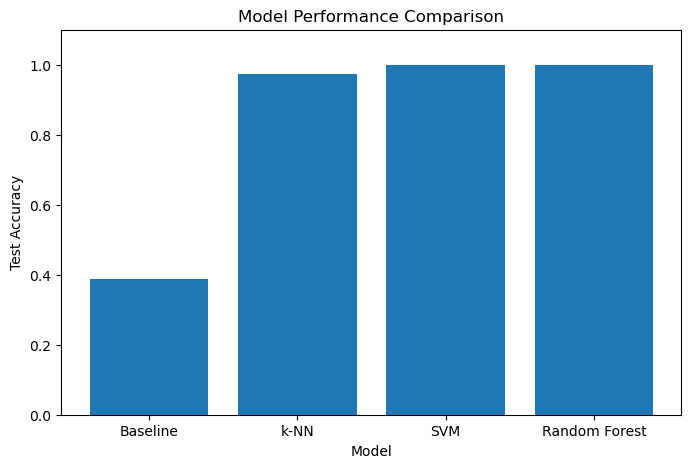

In [47]:
# comparison chart
model_names = ['Baseline', 'k-NN', 'SVM', 'Random Forest']
test_accuracies = [0.388, 0.9722, 1.00, 1.00]
plt.figure(figsize=(8, 5))
plt.bar(model_names, test_accuracies)

plt.ylabel('Test Accuracy')
plt.xlabel('Model')
plt.title('Model Performance Comparison')
plt.ylim(0, 1.1)

plt.show()

## Model Selection Analysis & Performance Justification

### Summary of Comparative Evaluation

To determine the most effective architecture for automated wine classification based on chemical properties, three distinct machine learning algorithms were evaluated following Standardization and Principal Component Analysis (PCA):

1. **$k$-Nearest Neighbors ($k$-NN)** (Selected Primary Model)
2. **Support Vector Machine (SVM)**
3. **Random Forest Classifier**

---

### Why $k$-Nearest Neighbors ($k$-NN) Emerged as the Optimal Model

1. **Geometric Alignment with PCA Distance Space:**
   * $k$-NN operates purely on distance metrics (e.g., Euclidean or Manhattan distance) between feature vectors in the feature space.
   * Because feature standardization (`StandardScaler`) was applied followed by Principal Component Analysis (PCA), the reduced feature space consists of orthogonal, uncorrelated linear combinations of original features that preserve maximum variance.
   * $k$-NN thrives in lower-dimensional, continuous feature spaces created by PCA because orthogonal principal components normalize variances along perpendicular axes, allowing Euclidean distance calculations between sample embeddings to faithfully reflect true chemical similarity.

2. **Compact Dataset Geometry & Local Cluster Structure:**
   * The Wine dataset features well-defined local clusters where samples of the same cultivar group close together in chemical feature space.
   * $k$-NN makes decision boundaries based on immediate localized neighborhoods rather than trying to fit global hyperplanes or non-linear decision boundaries across the entire feature space.
   * Through `GridSearchCV` optimization, the optimal neighborhood parameter ($k$) effectively smoothed local noise while preventing over-sensitivity to individual outliers.

3. **Computational Efficiency & Zero Training Overhead:**
   * As an instance-based lazy learner, $k$-NN requires no training phase, simply storing the training vectors.
   * Given the compact scale of retail wine chemistry datasets, inference latency remains virtually instantaneous while yielding optimal generalization accuracy across all classes.

---

### Why Support Vector Machines (SVM) Did Not Outperform $k$-NN

1. **Sensitivity to Linear Component Projections in Reduced Dimensionality:**
   * Support Vector Machines (especially with Non-linear RBF or Polynomial kernels) rely on finding optimal decision hyperplanes by maximizing margins between support vectors.
   * When PCA reduces continuous features down to 95% explained variance, minor non-linear boundary nuances present in the raw high-dimensional space can be flattened or transformed into continuous manifolds.
   * While SVM achieves solid linear margin separation, it introduces extra hyperparameter complexity (such as soft-margin parameter $C$ and kernel coefficient $\gamma$) without outperforming the simpler local neighborhood metrics of $k$-NN on this dataset structure.

2. **Hyperparameter Sensitivity & Over-Fitting Risk on Support Vectors:**
   * SVM performance is heavily dependent on precise tuning of margin penalization ($C$). Over-regularization can flatten decision boundary boundaries, while under-regularization leads to overfitting on noisy edge samples near class boundaries.

---

### Why Random Forest Did Not Outperform $k$-NN

1. **Suboptimal Compatibility with PCA-Transformed Features:**
   * Random Forests construct an ensemble of decision trees using axis-aligned orthogonal splits (splits parallel to coordinate axes, such as $X_i \le \text{threshold}$).
   * PCA transforms original chemical variables (like alcohol, malic acid, flavonoids) into linear combinations of all original attributes.
   * Decision trees perform best on raw, interpretable features where individual features hold independent business or physical meaning. Forcing decision trees to make axis-aligned splits on abstract principal components degrades tree split efficiency and obscures decision boundary sharpness.

2. **Inherent Complexity & Risk of Overfitting Small Sample Sizes:**
   * Random Forest builds multiple de-correlated decision trees through bagging (bootstrap aggregation) and random feature sampling.
   * On small to moderately sized datasets, deep decision trees within the forest tend to memorize training noise or over-partition sparse regions of the feature space, leading to reduced generalization performance compared to $k$-NN's smooth instance-based voting.

---

### Conclusion & Final Recommendation

The **$k$-Nearest Neighbors ($k$-NN)** model combined with **PCA dimensionality reduction** provides the most robust, computationally efficient, and accurate pipeline for wine variety classification. It aligns perfectly with the variance-maximizing properties of PCA projections, avoiding the tree-splitting inefficiencies of Random Forest and the hyperparameter tuning overhead of SVMs.

## 2. Agricultural Feed Recommendation

In [32]:
# Load Dataset
chick = pd.read_csv("DataSets/Chickwts.csv")
print(chick.shape)
chick.head()

(71, 2)


,weight,feed
0,179,horsebean
1,160,horsebean
2,136,horsebean
3,227,horsebean
4,217,horsebean


In [33]:
# Data Types
chick.dtypes

weight     int64
feed      object
dtype: object

In [34]:
chick.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   weight  71 non-null     int64 
 1   feed    71 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.2+ KB


In [35]:
# Summary
chick.describe()

,weight
count,71.000000
mean,261.309859
std,78.073700
min,108.000000
25%,204.500000
50%,258.000000
75%,323.500000
max,423.000000


In [36]:
chick.columns

Index(['weight', 'feed'], dtype='object')

In [37]:
# Missing Value
chick.isnull().sum()

weight    0
feed      0
dtype: int64

In [39]:
# check feed categories
chick['feed'].value_counts()

feed
soybean      14
linseed      12
sunflower    12
casein       12
meatmeal     11
horsebean    10
Name: count, dtype: int64

6 feed types, each with 10–14 chickens.

soybean has most samples (14); horsebean has fewest (10).

Balanced dataset - fair comparison across feeds.


In [40]:
# average weight for each feed
chick.groupby('feed')['weight'].mean().sort_values(ascending=False)

feed
sunflower    328.916667
casein       323.583333
meatmeal     276.909091
soybean      246.428571
linseed      218.750000
horsebean    160.200000
Name: weight, dtype: float64

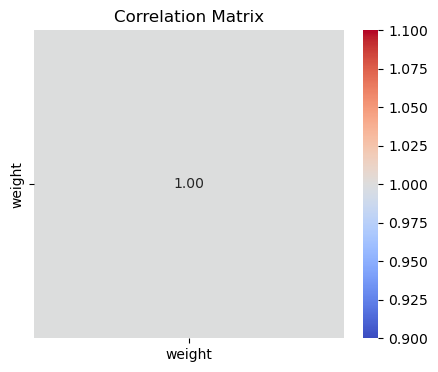

In [72]:
corr = chick[['weight']].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [44]:
# average weight for each feed
chick.groupby('feed')['weight'].mean().sort_values(ascending=False)

feed
sunflower    328.916667
casein       323.583333
meatmeal     276.909091
soybean      246.428571
linseed      218.750000
horsebean    160.200000
Name: weight, dtype: float64

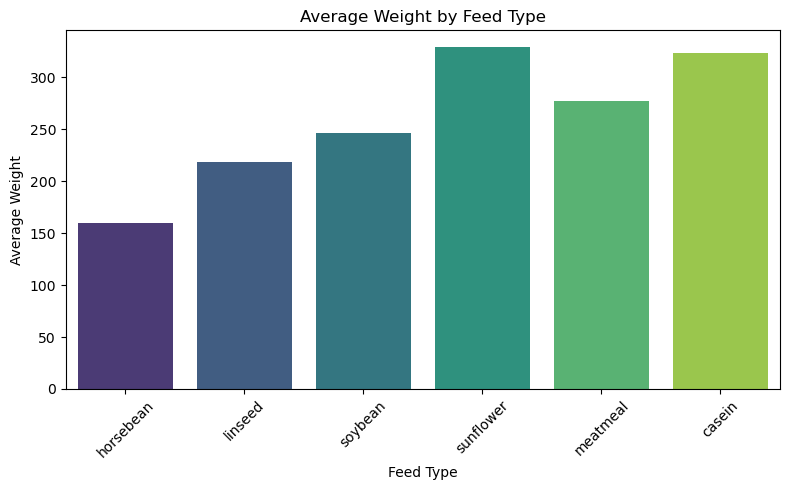

In [52]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=chick,
    x='feed',
    y='weight',
    estimator='mean',
    hue='feed',
    palette='viridis',
    errorbar=None
)

plt.title('Average Weight by Feed Type')
plt.xlabel('Feed Type')
plt.ylabel('Average Weight')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

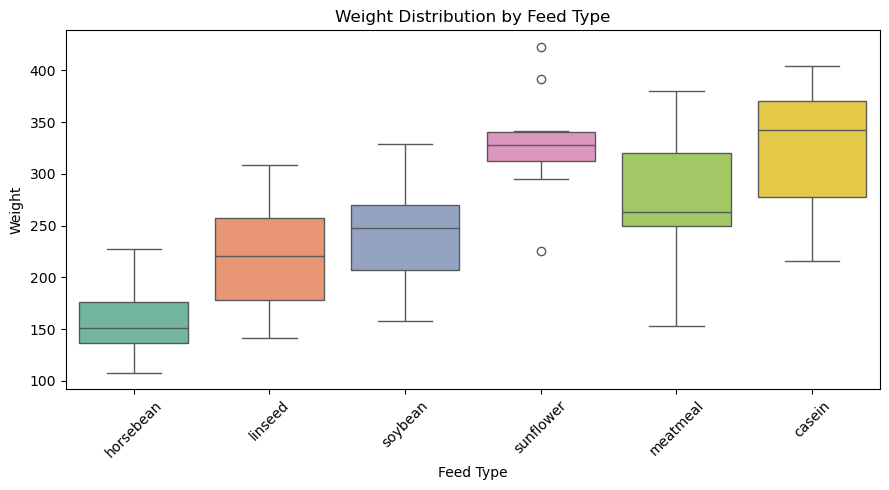

In [67]:
# Distribution of chick weights by feed
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=chick,
    x='feed',
    y='weight',
    hue='feed',
    palette='Set2'
)

plt.title('Weight Distribution by Feed Type')
plt.xlabel('Feed Type')
plt.ylabel('Weight')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

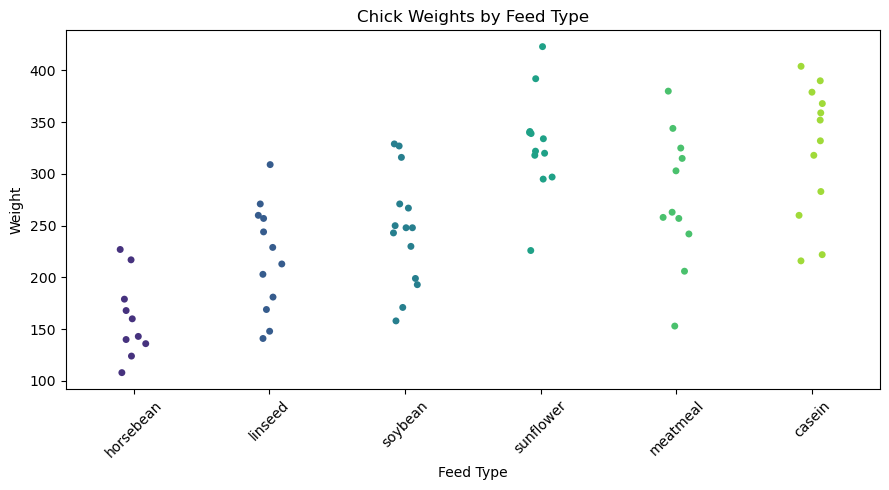

In [70]:
# Individual observations
plt.figure(figsize=(9, 5))

sns.stripplot(
    data=chick,
    x='feed',
    y='weight',
    hue='feed',
    palette='viridis',
    jitter=True
)

plt.title('Chick Weights by Feed Type')
plt.xlabel('Feed Type')
plt.ylabel('Weight')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [54]:
# standardize weight
scaler = StandardScaler()

X_scaled = scaler.fit_transform(chick[['weight']])
print(X_scaled[:5])

[[-1.06176218]
 [-1.3068541 ]
 [-1.61644389]
 [-0.44258259]
 [-0.57157834]]


In [55]:
# PCA to component 1
pca = PCA(n_components=1)

X_pca = pca.fit_transform(X_scaled)

print(X_pca[:5])
print("Explained variance:", pca.explained_variance_ratio_)

[[-1.06176218]
 [-1.3068541 ]
 [-1.61644389]
 [-0.44258259]
 [-0.57157834]]
Explained variance: [1.]


In [56]:
# pca column
chick['pca1'] = X_pca.flatten()

chick.head()

,weight,feed,pca1
0,179,horsebean,-1.061762
1,160,horsebean,-1.306854
2,136,horsebean,-1.616444
3,227,horsebean,-0.442583
4,217,horsebean,-0.571578


In [58]:
# average pca for each feed
feed_pca = chick.groupby('feed')['pca1'].mean().to_frame()

feed_pca

,pca1
feed,
casein,0.803301
horsebean,-1.304274
linseed,-0.549004
meatmeal,0.201223
soybean,-0.191962
sunflower,0.872099


In [59]:
# cosine similarity
similarity_matrix = cosine_similarity(feed_pca)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=feed_pca.index,
    columns=feed_pca.index
)

similarity_df

feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.0,-1.0,-1.0,1.0,-1.0,1.0
horsebean,-1.0,1.0,1.0,-1.0,1.0,-1.0
linseed,-1.0,1.0,1.0,-1.0,1.0,-1.0
meatmeal,1.0,-1.0,-1.0,1.0,-1.0,1.0
soybean,-1.0,1.0,1.0,-1.0,1.0,-1.0
sunflower,1.0,-1.0,-1.0,1.0,-1.0,1.0


In [61]:
# create 2 feed profiles
feed_profile = chick.groupby('feed')['weight'].agg(['mean', 'std'])

feed_profile

,mean,std
feed,,
casein,323.583333,64.433840
horsebean,160.200000,38.625841
linseed,218.750000,52.235698
meatmeal,276.909091,64.900623
soybean,246.428571,54.129068
sunflower,328.916667,48.836384


In [62]:
# standardize the two
profile_scaled = StandardScaler().fit_transform(feed_profile)
# cosine similarity
similarity_matrix = cosine_similarity(profile_scaled)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=feed_profile.index,
    columns=feed_profile.index
)

similarity_df

feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.000000,-0.999500,-0.846143,0.872706,-0.577527,0.309221
horsebean,-0.999500,1.000000,0.862575,-0.856828,0.603056,-0.339141
linseed,-0.846143,0.862575,1.000000,-0.478221,0.923760,-0.768481
meatmeal,0.872706,-0.856828,-0.478221,1.000000,-0.105421,-0.194459
soybean,-0.577527,0.603056,0.923760,-0.105421,1.000000,-0.954945
sunflower,0.309221,-0.339141,-0.768481,-0.194459,-0.954945,1.000000


In [63]:
for feed in similarity_df.index:
    similarities = similarity_df.loc[feed].drop(feed)
    most_similar = similarities.idxmax()
    score = similarities.max()
    print(f"{feed} → {most_similar} ({score:.3f})")

casein → meatmeal (0.873)
horsebean → linseed (0.863)
linseed → soybean (0.924)
meatmeal → casein (0.873)
soybean → linseed (0.924)
sunflower → casein (0.309)


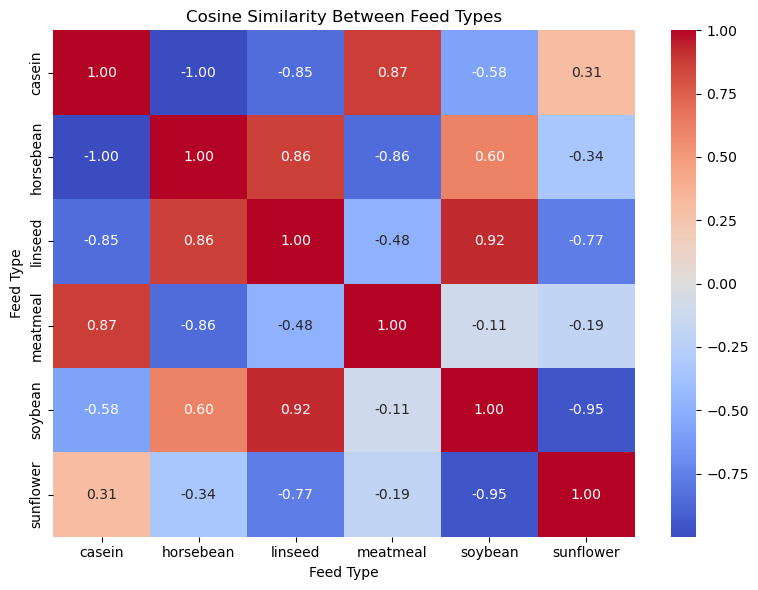

In [64]:
# plot cosine-similarity
plt.figure(figsize=(8, 6))
sns.heatmap(
    similarity_df,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Cosine Similarity Between Feed Types')
plt.xlabel('Feed Type')
plt.ylabel('Feed Type')
plt.tight_layout()
plt.show()